# 23CSE301 Machine Learning – Capstone Project

**Team No:** 8

**Project Title:** Healthcare Cost Prediction and Patient Risk Intelligence Platform

**Module:** Unsupervised Patient Clustering & Segmentation

### Overview
We perform unsupervised clustering on patient clinical and utilization metrics using K-Means, Agglomerative, DBSCAN, Gaussian Mixture, and Spectral Clustering.

In [12]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

import app.config as config
import app.preprocessing as preprocessing

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_theme(style='whitegrid')
np.random.seed(config.RANDOM_STATE)
print('Clustering libraries loaded successfully.')

Clustering libraries loaded successfully.


In [13]:
# Load dataset and preprocess for clustering
df_raw = pd.read_csv(config.DATA_PATH)
df_cluster = df_raw.drop(columns=[c for c in [config.REGRESSION_TARGET, config.CLASSIFICATION_TARGET, 'person_id', 'risk_score'] if c in df_raw.columns])
df_cluster

,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,dependents,...,kidney_disease,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,had_major_procedure
0,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,1,...,0,0,1,0,1,0,2,0,1,0
1,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,1,...,0,0,1,1,0,0,1,0,1,0
2,68,Male,North,Rural,40700.0,HS,Married,Retired,5,3,...,0,0,0,1,1,0,2,1,0,0
3,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,3,...,0,0,0,0,1,0,0,1,0,0
4,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,0,...,0,0,1,0,2,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,50,Male,West,Urban,127200.0,No HS,Married,Employed,2,0,...,0,0,0,0,0,0,1,0,0,0
99996,42,Male,East,Suburban,21600.0,HS,Married,Employed,2,0,...,0,0,0,0,0,0,0,0,0,0
99997,41,Male,West,Rural,81900.0,HS,Divorced,Unemployed,1,0,...,0,0,0,0,1,0,1,0,0,0
99998,51,Female,South,Urban,43400.0,Doctorate,Single,Unemployed,3,2,...,0,0,0,1,0,0,2,2,1,0


In [14]:
# Handle missing values
# Categorical / string columns
for col in df_cluster.select_dtypes(include=['object', 'str']).columns:
    df_cluster[col] = df_cluster[col].fillna(df_cluster[col].mode()[0])

# Numerical columns
for col in df_cluster.select_dtypes(include=[np.number]).columns:
    df_cluster[col] = df_cluster[col].fillna(df_cluster[col].median())

In [15]:
# One-hot encoding
df_encoded = pd.get_dummies(df_cluster, drop_first=True)

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)
print('Scaled clustering data shape:', X_scaled.shape)

Scaled clustering data shape: (100000, 69)


In [17]:
# Fit clustering models on subsample for efficiency
sample_idx = np.random.choice(len(X_scaled), size=5000, replace=False)
X_sample = X_scaled[sample_idx]

models = {
    'K-Means': KMeans(n_clusters=4, random_state=42, n_init=10),
    'Agglomerative': AgglomerativeClustering(n_clusters=4, linkage='ward'),
    'DBSCAN': DBSCAN(eps=1.5, min_samples=5),
    'Gaussian Mixture': GaussianMixture(n_components=4, random_state=42),
    'Spectral Clustering': SpectralClustering(n_clusters=4, random_state=42, affinity='nearest_neighbors')
}

cluster_results = []
for name, model in models.items():
    labels = model.fit_predict(X_sample)
    unique_labels = np.unique(labels)
    n_clusters = len(unique_labels)
    print(f"{name}: {n_clusters} unique cluster labels")
    if n_clusters > 1:
        sil = silhouette_score(X_sample, labels)
        db = davies_bouldin_score(X_sample, labels)
        ch = calinski_harabasz_score(X_sample, labels)
        cluster_results.append({
            'Algorithm': name,
            'Clusters': n_clusters,
            'Silhouette Score': sil,
            'Davies-Bouldin Index': db,
            'Calinski-Harabasz Index': ch
        })

    else:
        cluster_results.append({
            'Algorithm': name,
            'Clusters': n_clusters,
            'Silhouette Score': np.nan,
            'Davies-Bouldin Index': np.nan,
            'Calinski-Harabasz Index': np.nan
        })
df_cluster_res = pd.DataFrame(cluster_results)
df_cluster_res = df_cluster_res.sort_values(
    by='Silhouette Score',
    ascending=False,
    na_position='last'
).reset_index(drop=True)

df_cluster_res

K-Means: 4 unique cluster labels
Agglomerative: 4 unique cluster labels
DBSCAN: 1 unique cluster labels
Gaussian Mixture: 4 unique cluster labels
Spectral Clustering: 4 unique cluster labels


,Algorithm,Clusters,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,Spectral Clustering,4,0.151043,2.023039,81.581966
1,Agglomerative,4,0.046147,4.367275,112.544570
2,Gaussian Mixture,4,0.023495,4.453753,107.092071
3,K-Means,4,0.014812,4.417245,152.716526
4,DBSCAN,1,NaN,NaN,NaN


In [27]:
# Rank clustering algorithms using all 3 metrics

valid_clusters = df_cluster_res.dropna().copy()

valid_clusters['Silhouette_Rank'] = valid_clusters[
    'Silhouette Score'
].rank(ascending=False)

valid_clusters['DB_Rank'] = valid_clusters[
    'Davies-Bouldin Index'
].rank(ascending=True)

valid_clusters['CH_Rank'] = valid_clusters[
    'Calinski-Harabasz Index'
].rank(ascending=False)

# Average ranking
valid_clusters['Overall_Rank'] = (
    valid_clusters['Silhouette_Rank'] +
    valid_clusters['DB_Rank'] +
    valid_clusters['CH_Rank']
) / 3

# Sort best to worst
valid_clusters = valid_clusters.sort_values(
    'Overall_Rank'
).reset_index(drop=True)

valid_clusters

,Algorithm,Clusters,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index,Silhouette_Rank,DB_Rank,CH_Rank,Overall_Rank
0,Spectral Clustering,4,0.151043,2.023039,81.581966,1.0,1.0,4.0,2.000000
1,Agglomerative,4,0.046147,4.367275,112.544570,2.0,2.0,2.0,2.000000
2,K-Means,4,0.014812,4.417245,152.716526,4.0,3.0,1.0,2.666667
3,Gaussian Mixture,4,0.023495,4.453753,107.092071,3.0,4.0,3.0,3.333333


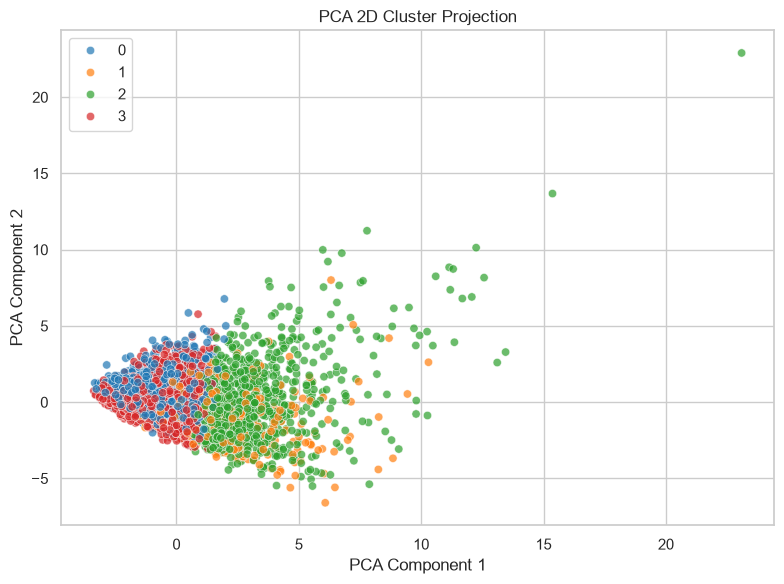

In [26]:
# PCA 2D Visualization
# Apply PCA
pca = PCA(n_components=2)

# Convert high-dimensional data into 2 dimensions
X_pca = pca.fit_transform(X_sample)

# Visualization
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=labels_best,
    palette='tab10',
    legend='full',
    alpha=0.7
)

plt.title('PCA 2D Cluster Projection')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')

plt.tight_layout()
plt.show()

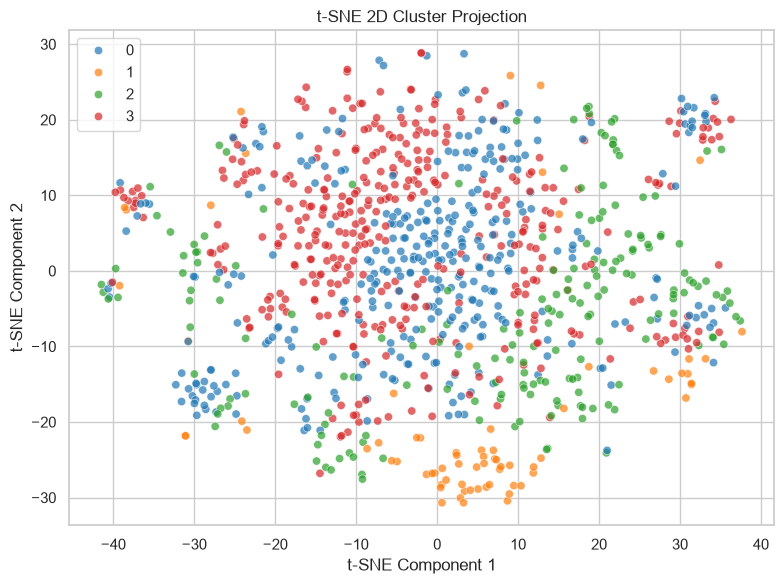

In [25]:
# t-SNE Visualization
np.random.seed(42)
tsne_idx = np.random.choice(len(X_sample), size=min(1000, len(X_sample)), replace=False )
X_tsne_input = X_sample[tsne_idx]
labels_tsne = labels_best[tsne_idx]
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_tsne_input)
# Visualization 
plt.figure(figsize=(8, 6))
# t-SNE
sns.scatterplot(
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    hue=labels_tsne,
    palette='tab10',
    legend='full',
    alpha=0.7
)
plt.title('t-SNE 2D Cluster Projection')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.tight_layout()
plt.show()